In [1]:
import numpy as np
import pandas as pd
from datetime import datetime as dt
from openbb import obb

import os

import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

import OpenBBConvenienceFunctions as obb_cf
import PlottingFunctions as plot_func

from sklearn.preprocessing import StandardScaler

In [2]:
from API_Keys import FMP_API
from File_Paths import raw_data_filepath

In [3]:
start = '2010-01-01'
end = '2025-12-31'

In [4]:
date_list = pd.date_range(start=start, end=end, freq='B').strftime("%Y-%m-%d").to_list()

### FUTURES OPEN INTEREST / COT REPORT

#### Contracts to Examine

In [15]:
obb_cf.get_commands_by_heading('regulators.cftc')

{'.regulators.cftc.cot_search': ['cftc'], '.regulators.cftc.cot': ['cftc']}

In [19]:
obb_cf.explore_query_inputs(".regulators.cftc.cot", provider="cftc")

{'report_type': FieldInfo(annotation=Literal['legacy', 'disaggregated', 'financial', 'supplemental'], required=False, default='legacy', description="The type of report to retrieve. Set `id` as 'all' to return all items in the report\n            type (default date range returns the latest report). The Legacy report is broken down by exchange\n            with reported open interest further broken down into three trader classifications: commercial,\n            non-commercial and non-reportable. The Disaggregated reports are broken down by Agriculture and\n            Natural Resource contracts. The Disaggregated reports break down reportable open interest positions\n            into four classifications: Producer/Merchant, Swap Dealers, Managed Money and Other Reportables.\n            The Traders in Financial Futures (TFF) report includes financial contracts. The TFF report breaks\n            down the reported open interest into five classifications: Dealer, Asset Manager, Leveraged 

In [ ]:
cot_search = obb.regulators.cftc.cot_search()
cot_search_df = cot_search.to_dataframe()

In [29]:
cot_search_df[(cot_search_df['category']=='FINANCIAL INSTRUMENTS')&(cot_search_df['commodity_name']=='S&P BROAD BASED STOCK INDICES')]

,code,name,category,subcategory,commodity_name
72,13874I,E-MINI S&P TECHNOLOGY INDEX,FINANCIAL INSTRUMENTS,STOCK INDICES,S&P BROAD BASED STOCK INDICES
73,138748,E-MINI S&P CONSU STAPLES INDEX,FINANCIAL INSTRUMENTS,STOCK INDICES,S&P BROAD BASED STOCK INDICES
74,13874A,E-MINI S&P 500,FINANCIAL INSTRUMENTS,STOCK INDICES,S&P BROAD BASED STOCK INDICES
75,138749,E-MINI S&P ENERGY INDEX,FINANCIAL INSTRUMENTS,STOCK INDICES,S&P BROAD BASED STOCK INDICES
76,13874W,ADJUSTED INT RATE S&P 500 TOTL,FINANCIAL INSTRUMENTS,STOCK INDICES,S&P BROAD BASED STOCK INDICES
77,13874+,S&P 500 Consolidated,FINANCIAL INSTRUMENTS,STOCK INDICES,S&P BROAD BASED STOCK INDICES
78,13874C,E-MINI S&P FINANCIAL INDEX,FINANCIAL INSTRUMENTS,STOCK INDICES,S&P BROAD BASED STOCK INDICES
79,33874A,E-MINI S&P 400 STOCK INDEX,FINANCIAL INSTRUMENTS,STOCK INDICES,S&P BROAD BASED STOCK INDICES
80,13874U,MICRO E-MINI S&P 500 INDEX,FINANCIAL INSTRUMENTS,STOCK INDICES,S&P BROAD BASED STOCK INDICES
81,13874J,E-MINI S&P UTILITIES INDEX,FINANCIAL INSTRUMENTS,STOCK INDICES,S&P BROAD BASED STOCK INDICES


#### Raw Data Download

In [ ]:
# S&P 500 E-mini Futures Open Interest via CFTC COT (code 13874A)

# cot_raw = obb.regulators.cftc.cot('13874+', provider='cftc')
# cot_df = cot_raw.to_df()
# cot_df.index = pd.to_datetime(cot_df.index)

In [1]:
# later renamed to COT_Reports.parquet

# cot_df.to_parquet(os.path.join(raw_data_filepath, r"OpenInterest.parquet"))

#### Data Exploration

In [5]:
cot_data = obb_cf.read_file(raw_data_filepath, r"COT_Reports.parquet")

# Removing white space
cot_data['cftc_market_code'] = cot_data['cftc_market_code'].str.strip(" ")
cot_data['cftc_commodity_code'] = cot_data['cftc_commodity_code'].str.strip(" ")

# Filtering columns that have more than one unique value (i.e. useful information)
cot_cols = []
for i in cot_data.columns:
    if cot_data[i].nunique() < 2:
        continue
    else:
        cot_cols.append(i)

cot_data = cot_data[cot_cols]

In [6]:
# Load SP500 price data and compute 1-month forward returns
sp500_prices = obb_cf.read_file(raw_data_filepath, r"SP500_price_data.parquet")
sp500_prices.index = pd.to_datetime(sp500_prices.index, unit='ns')

# 1-month forward return: price 21 trading days ahead vs current
sp500_prices['fwd_return_1m'] = sp500_prices['close'].shift(-21) / sp500_prices['close'] - 1
sp500_fwd_returns = sp500_prices[['fwd_return_1m']]
sp500_fwd_returns.index = sp500_fwd_returns.index.as_unit('ms')

In [7]:
# Load 1-month forward volatility
fwd_vol = obb_cf.read_file(raw_data_filepath, r"ForwardVol.parquet")
fwd_vol.index = pd.to_datetime(fwd_vol.index, unit='ms')

In [8]:
cot_data = cot_data.merge(fwd_vol, how='left', right_index=True, left_index=True).dropna()

##### OPEN INTEREST 

In [9]:
oi_cols = [
    'open_interest_all', 'forward_vol_1m',
    'pct_of_oi_noncomm_long_all', 'pct_of_oi_noncomm_short_all', # Speculator oi
    'pct_of_oi_comm_long_all','pct_of_oi_comm_short_all', # Hedger oi 
    'pct_of_oi_nonrept_long_all', 'pct_of_oi_nonrept_short_all' # All long and short
    ]

oi_df = cot_data[oi_cols]
oi_df['Delta_open_interest'] = oi_df['open_interest_all'].pct_change()

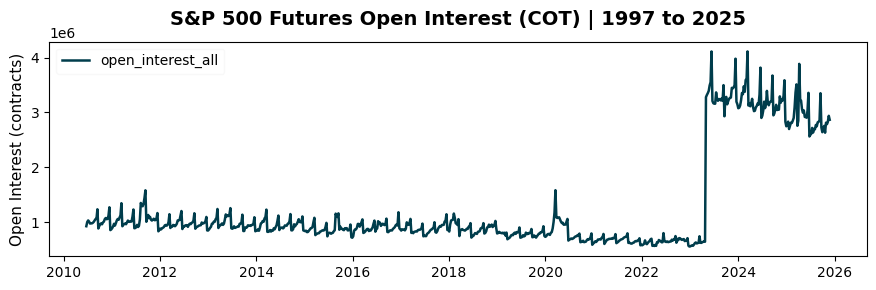

In [83]:
# Open interest jumps in 2023 - unknown reason why. Distorts remaining plots

plot_func.plot_line(oi_df[['open_interest_all']], title='S&P 500 Futures Open Interest (COT) | 1997 to 2025',
                    ylabel='Open Interest (contracts)', figsize=(9,3), dark=False);

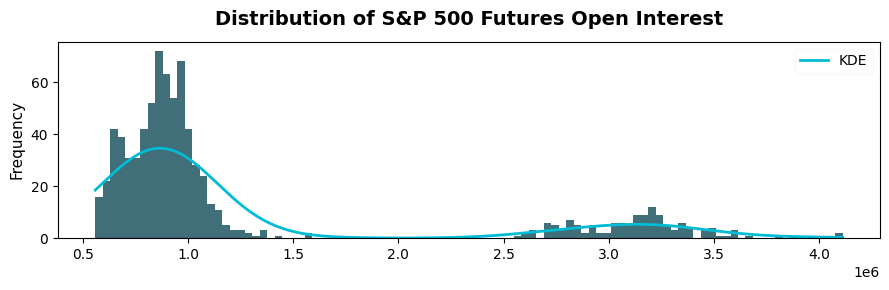

In [84]:
plot_func.plot_histogram(oi_df['open_interest_all'], bins=100,
                         title='Distribution of S&P 500 Futures Open Interest',
                         figsize=(9,3), dark=False, kde=True);

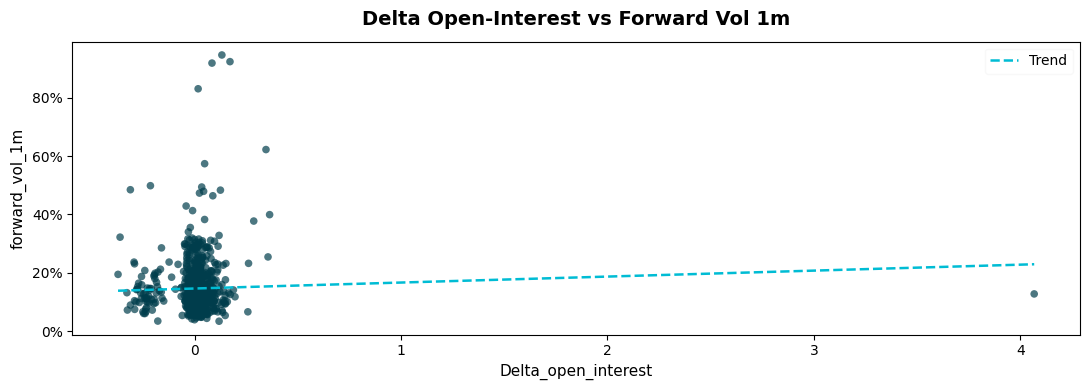

In [77]:
# No clear relationship between open interest and forward vol (even removing the outlier caused by jump in approx. 2023)

plot_func.plot_scatter(oi_df, x='Delta_open_interest', y='forward_vol_1m', percent_y=True,
                       dark=False, figsize=(11,4), title='Delta Open-Interest vs Forward Vol 1m', trend_line=True);

In [10]:
config_list = []

for i in range(2, len(oi_cols)):
    config_list.append({'type':'scatter', 
                        'data':oi_df, 
                        'x':oi_cols[i], 
                        'y':'forward_vol_1m', 
                        'title':f"{oi_cols[i]} vs Forward Vol 1m", 
                        'percent_x':True,
                        'trend_line':True})

(<Figure size 1400x1350 with 6 Axes>,
 array([[<Axes: title={'center': 'pct_of_oi_noncomm_long_all vs Forward Vol 1m'}, xlabel='pct_of_oi_noncomm_long_all', ylabel='forward_vol_1m'>,
         <Axes: title={'center': 'pct_of_oi_noncomm_short_all vs Forward Vol 1m'}, xlabel='pct_of_oi_noncomm_short_all', ylabel='forward_vol_1m'>],
        [<Axes: title={'center': 'pct_of_oi_comm_long_all vs Forward Vol 1m'}, xlabel='pct_of_oi_comm_long_all', ylabel='forward_vol_1m'>,
         <Axes: title={'center': 'pct_of_oi_comm_short_all vs Forward Vol 1m'}, xlabel='pct_of_oi_comm_short_all', ylabel='forward_vol_1m'>],
        [<Axes: title={'center': 'pct_of_oi_nonrept_long_all vs Forward Vol 1m'}, xlabel='pct_of_oi_nonrept_long_all', ylabel='forward_vol_1m'>,
         <Axes: title={'center': 'pct_of_oi_nonrept_short_all vs Forward Vol 1m'}, xlabel='pct_of_oi_nonrept_short_all', ylabel='forward_vol_1m'>]],
       dtype=object))

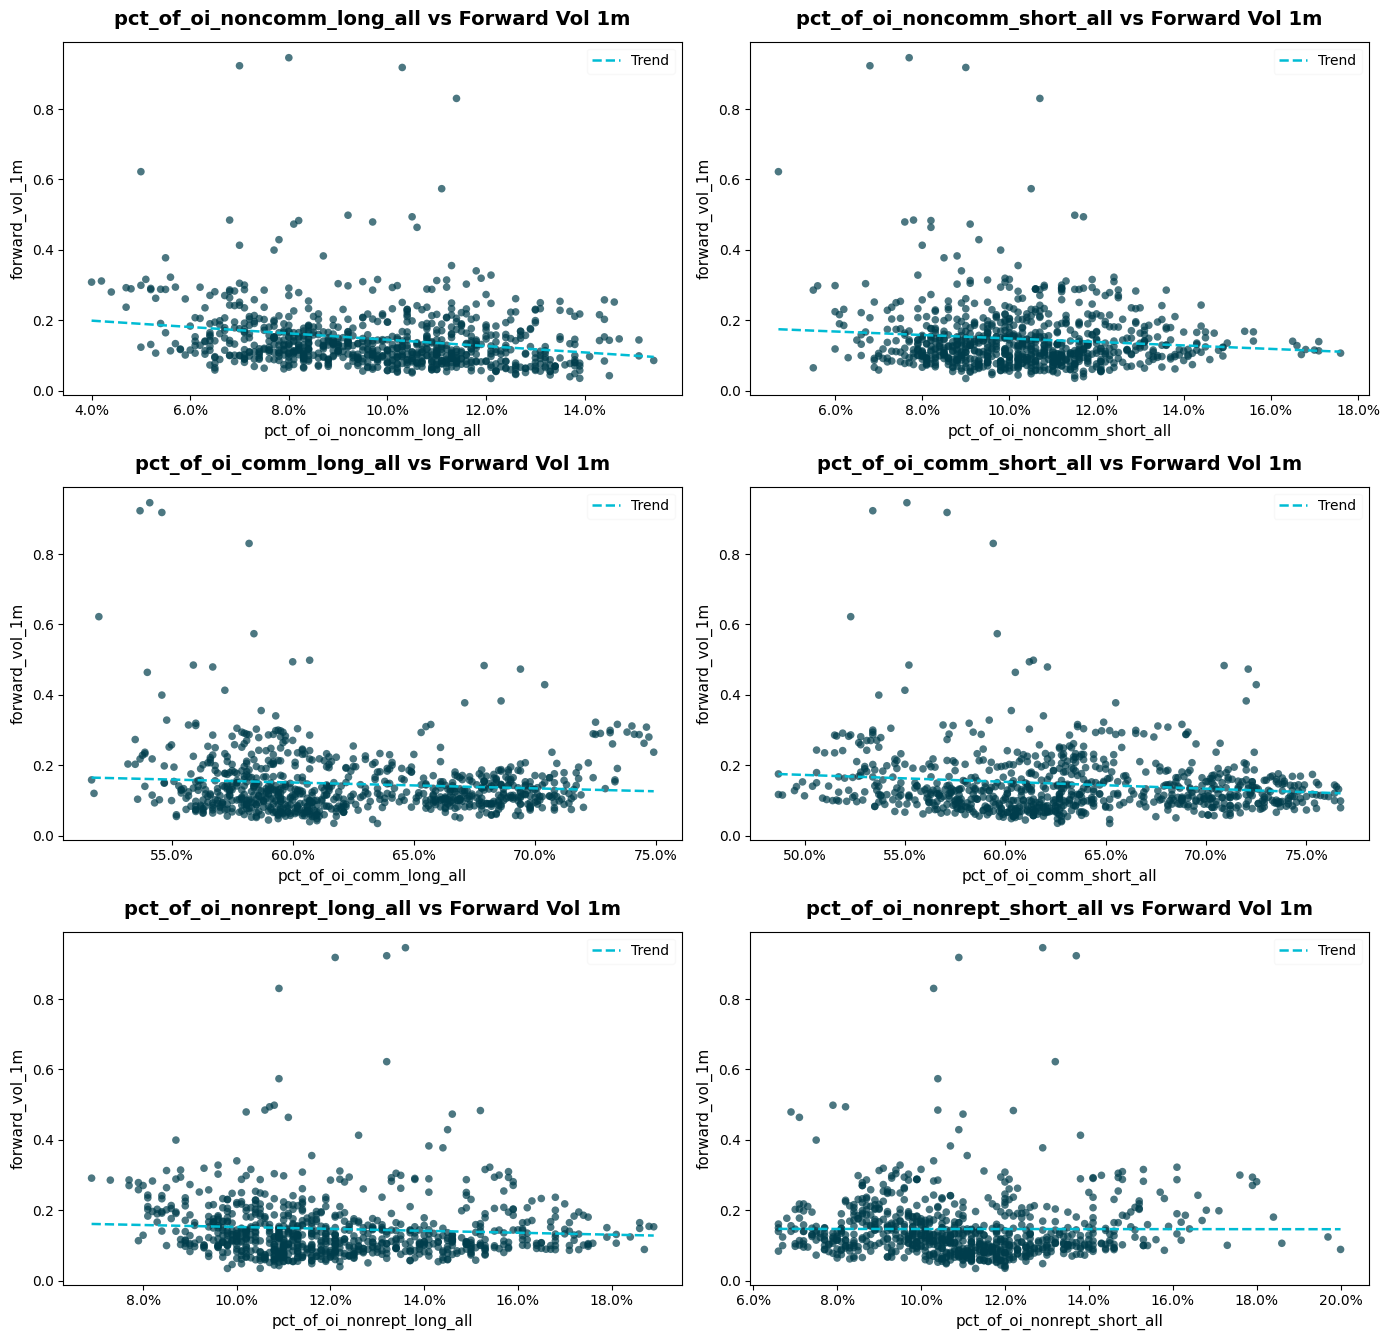

In [11]:
plot_func.plot_subplots(plot_configs=config_list, ncols=2)

#### POSITIONING

In [27]:
position_dict = {
    'speculative_positions_all' : ['noncomm_positions_long_all', 'noncomm_positions_short_all'],
    'hedging_positions_all' : ['comm_positions_long_all','comm_positions_short_all'],
    'small_trader_positions_all' : ['nonrept_positions_long_all','nonrept_positions_short_all']
}

positioning_df = pd.DataFrame()

for key, values in position_dict.items():
    positioning_df[key] = cot_data[values[0]] + cot_data[values[1]] 

# proportions of positions
positioning_df = positioning_df.T.transform(lambda x: x/x.sum()).T

positioning_df = positioning_df.merge(fwd_vol, how='left', left_index=True, right_index=True).dropna()

positioning_df['year'] = positioning_df.index.year

In [28]:
positioning_df

,speculative_positions_all,hedging_positions_all,small_trader_positions_all,forward_vol_1m,year
date,,,,,
2010-06-22,0.084619,0.752727,0.162654,0.236986,2010
2010-06-29,0.078376,0.763982,0.157642,0.203628,2010
2010-07-06,0.080277,0.755001,0.164723,0.207332,2010
2010-07-13,0.087087,0.747209,0.165704,0.205379,2010
2010-07-20,0.089332,0.752734,0.157934,0.178908,2010
...,...,...,...,...,...
2025-10-28,0.132966,0.746364,0.120670,0.149366,2025
2025-11-04,0.133843,0.743368,0.122789,0.141758,2025
2025-11-10,0.134029,0.747000,0.118971,0.127242,2025


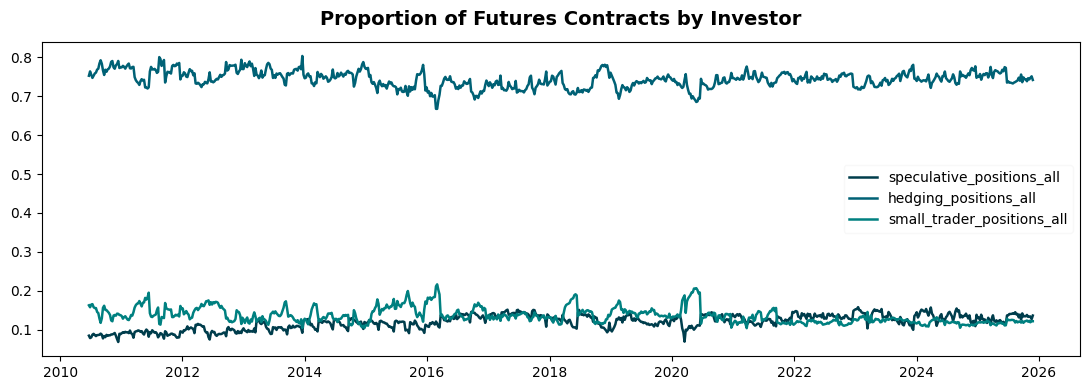

In [29]:
plot_func.plot_line(positioning_df[['speculative_positions_all',
                                    'hedging_positions_all',
                                    'small_trader_positions_all']], dark=False, title='Proportion of Futures Contracts by Investor', figsize=(11,4));

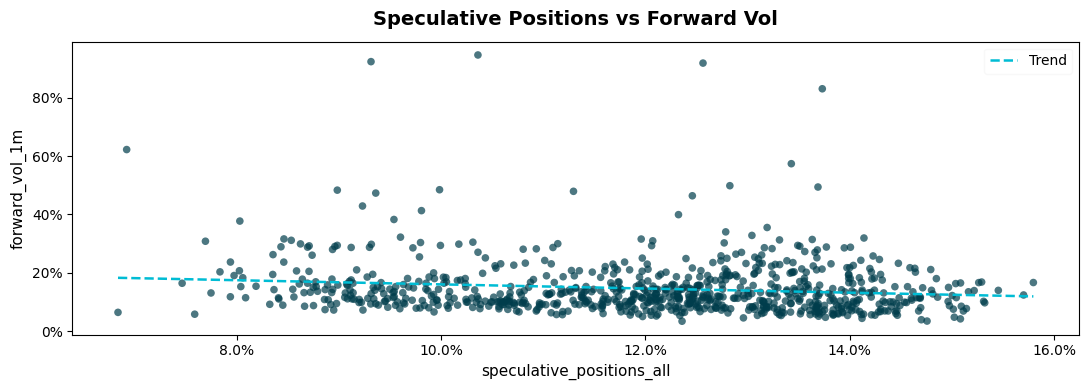

In [30]:
plot_func.plot_scatter(positioning_df, x='speculative_positions_all', y='forward_vol_1m',
                       title='Speculative Positions vs Forward Vol', dark=False, figsize=(11,4), percent_x=True, percent_y=True,
                       trend_line=True);

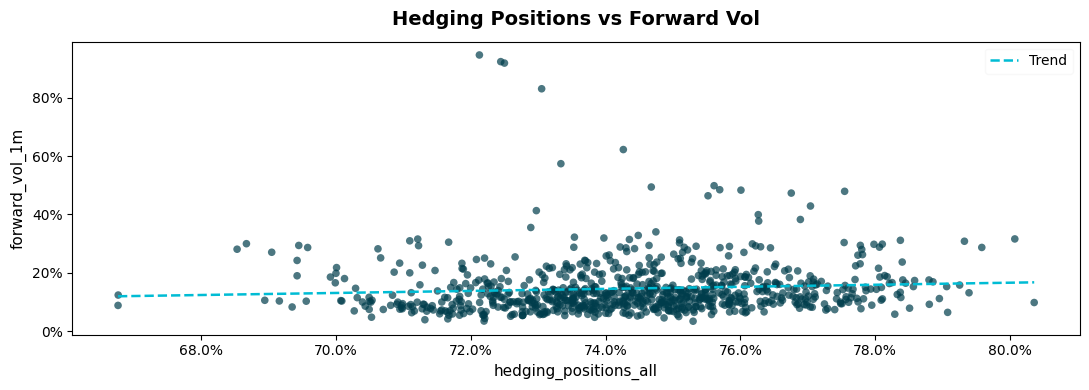

In [31]:
plot_func.plot_scatter(positioning_df, x='hedging_positions_all', y='forward_vol_1m',
                       title='Hedging Positions vs Forward Vol', dark=False, figsize=(11,4), percent_x=True, percent_y=True,
                       trend_line=True, colors=plot_func.TEAL_SEQUENCE);

##### Speculator Positioning

In [32]:
# Long Speculative | noncomm_positions_long_all | noncomm_positions_short_all
speculator_positioning = cot_data[['noncomm_positions_long_all','noncomm_positions_short_all']]
speculator_positioning['net_speculative_positioning'] = speculator_positioning['noncomm_positions_long_all'] - speculator_positioning['noncomm_positions_short_all']
speculator_positioning = obb_cf.append_returns(speculator_positioning, price_column='net_speculative_positioning')
speculator_positioning.rename(columns={'simple_return':'pct_change', 'log_return':'log_change'}, inplace=True)

# Merge forward returns and forward volatility into speculator_positioning

speculator_positioning = pd.merge_asof(
    speculator_positioning,
    sp500_fwd_returns,
    left_index=True,
    right_index=True,
    direction='forward'
)

speculator_positioning = pd.merge_asof(
    speculator_positioning,
    fwd_vol,
    left_index=True,
    right_index=True,
    direction='forward'
).dropna()

c:\ProjectsDannyDavis\DDVenv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


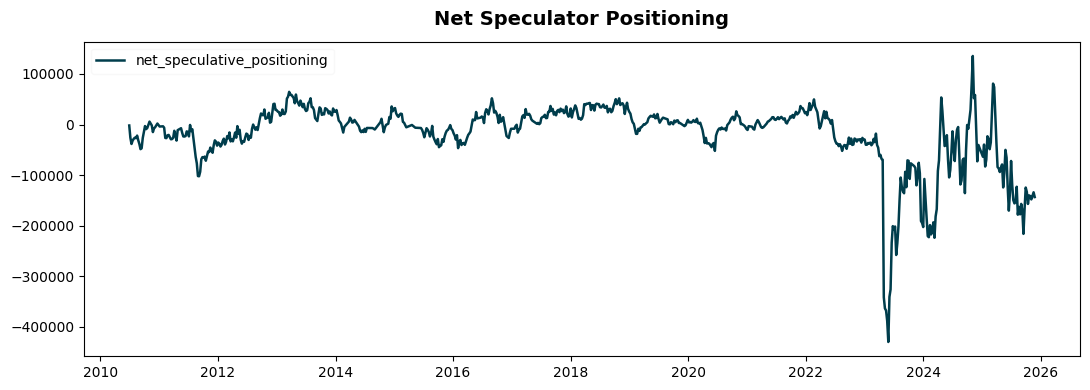

In [33]:
plot_func.plot_line(speculator_positioning, y='net_speculative_positioning', title='Net Speculator Positioning',
                    figsize=(11,4), dark=False);

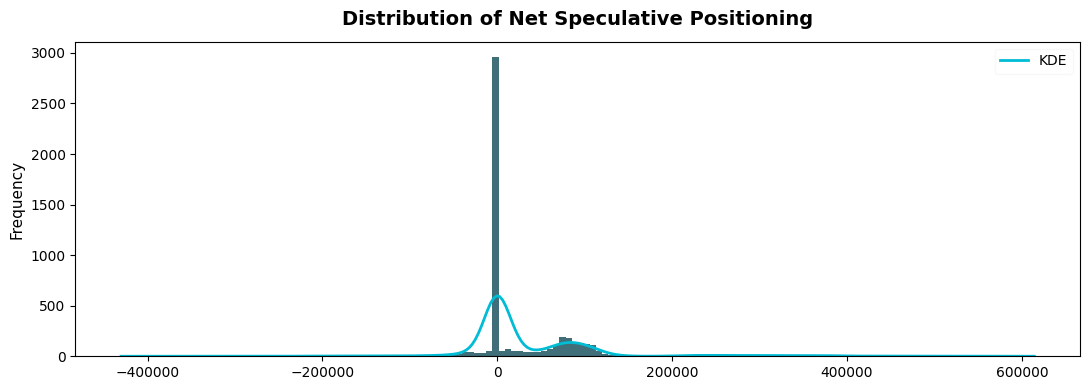

In [34]:
plot_func.plot_histogram(speculator_positioning, bins=150, title='Distribution of Net Speculative Positioning',
                         figsize=(11,4), dark=False);

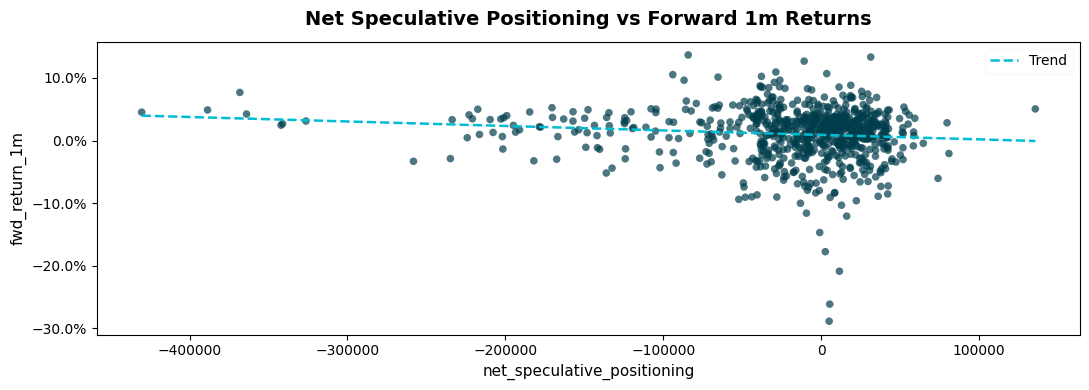

In [35]:
# Little-to-negative relationship between fwd returns and net market positioning

plot_func.plot_scatter(speculator_positioning, x='net_speculative_positioning', y='fwd_return_1m', percent_y=True,
                       figsize=(11,4), trend_line=True, dark=False, title='Net Speculative Positioning vs Forward 1m Returns');

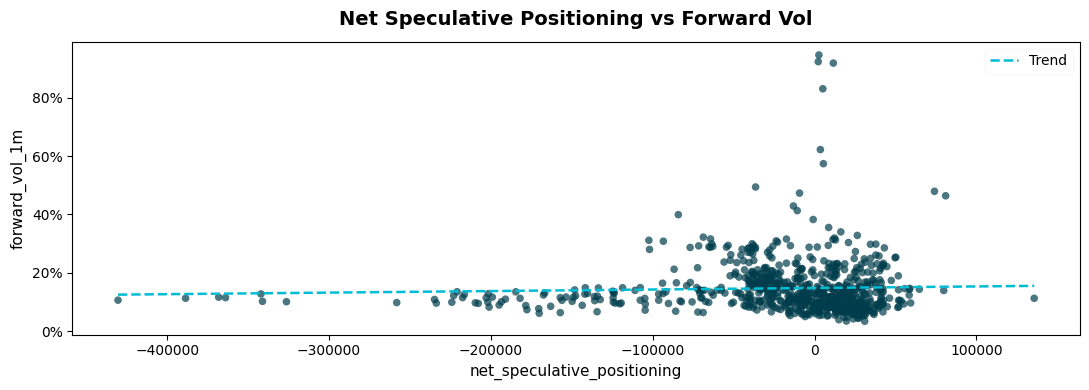

In [36]:
# Net positioning itself tells very little about forward vol

plot_func.plot_scatter(speculator_positioning, x='net_speculative_positioning', y='forward_vol_1m', percent_y=True,
                       figsize=(11,4), trend_line=True, dark=False, title='Net Speculative Positioning vs Forward Vol');

#### CONCENTRATION

In [18]:
conc_cols = [
    'conc_gross_le_4_tdr_long',
    'conc_gross_le_4_tdr_short',
    'conc_gross_le_8_tdr_long',
    'conc_gross_le_8_tdr_short',
]

fwd_vol = obb_cf.read_file(raw_data_filepath, r"ForwardVol.parquet")
fwd_vol.index = pd.to_datetime(fwd_vol.index, unit='ms')

conc_df = cot_data[conc_cols].merge(fwd_vol, how='left', left_index=True, right_index=True).dropna()

In [20]:
conc_df

,conc_gross_le_4_tdr_long,conc_gross_le_4_tdr_short,conc_gross_le_8_tdr_long,conc_gross_le_8_tdr_short,forward_vol_1m
date,,,,,
2010-06-22,16.4,11.5,24.5,19.9,0.236986
2010-06-29,15.6,10.7,23.8,18.5,0.203628
2010-07-06,16.0,9.1,24.3,16.2,0.207332
2010-07-13,16.3,9.4,25.1,16.5,0.205379
2010-07-20,16.5,9.9,25.8,17.9,0.178908
...,...,...,...,...,...
2025-10-28,13.8,21.8,21.1,34.2,0.149366
2025-11-04,13.5,22.0,20.4,33.9,0.141758
2025-11-10,13.4,22.4,20.0,34.0,0.127242


(<Figure size 1400x900 with 4 Axes>,
 array([[<Axes: title={'center': 'conc_gross_le_4_tdr_long vs Forward Vol 1m'}, xlabel='conc_gross_le_4_tdr_long', ylabel='forward_vol_1m'>,
         <Axes: title={'center': 'conc_gross_le_4_tdr_long Over Time'}, ylabel='% of OI'>],
        [<Axes: title={'center': 'conc_gross_le_4_tdr_short vs Forward Vol 1m'}, xlabel='conc_gross_le_4_tdr_short', ylabel='forward_vol_1m'>,
         <Axes: title={'center': 'conc_gross_le_4_tdr_short Over Time'}, ylabel='% of OI'>]],
       dtype=object))

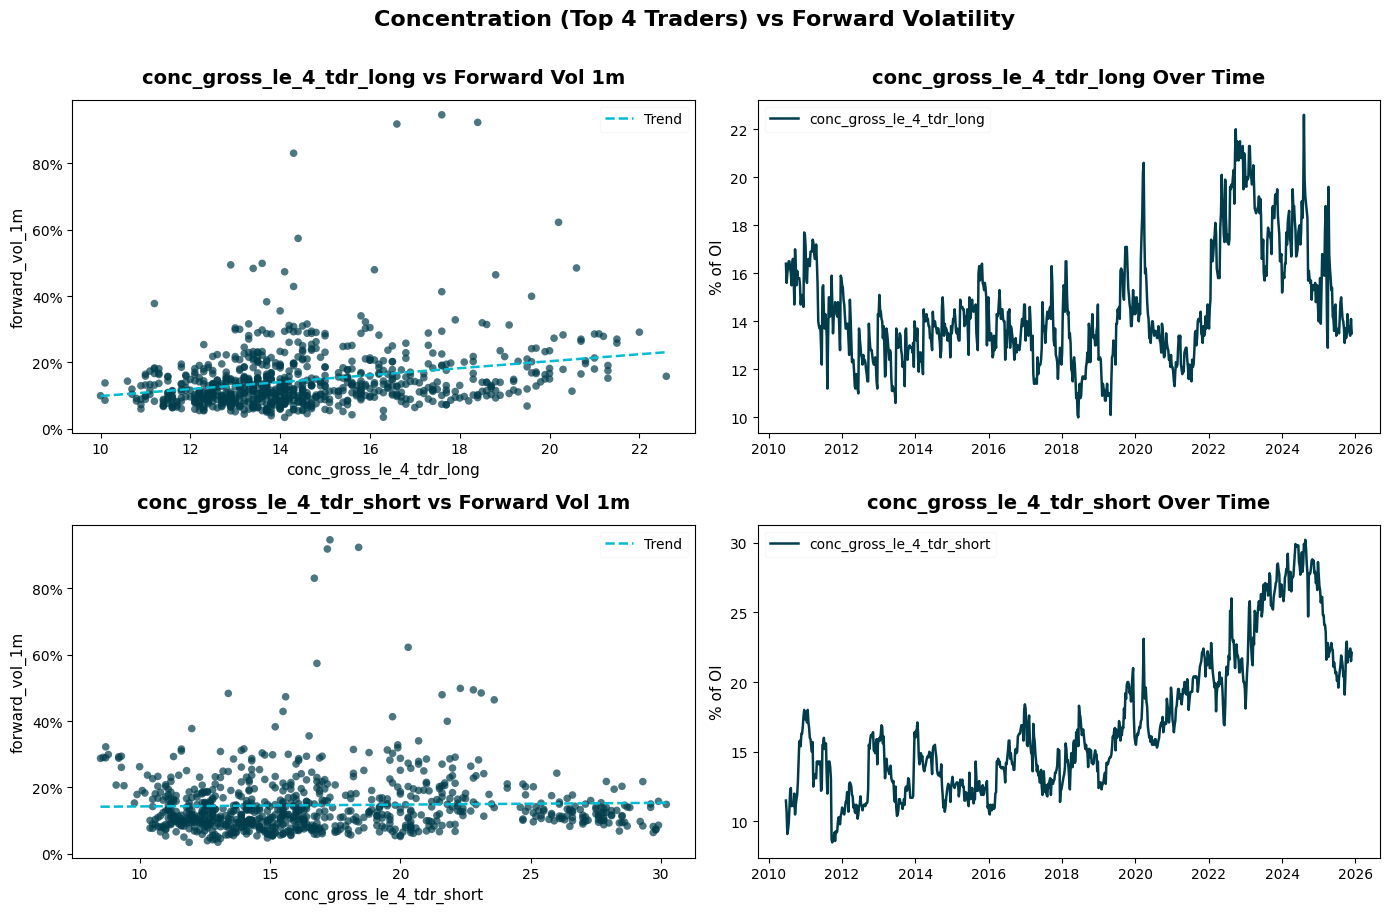

In [38]:
config_list_4 = []

for col in ['conc_gross_le_4_tdr_long', 'conc_gross_le_4_tdr_short']:
    config_list_4.append({
        'type': 'scatter',
        'data': conc_df,
        'x': col,
        'y': 'forward_vol_1m',
        'title': f"{col} vs Forward Vol 1m",
        'percent_y': True,
        'trend_line': True,
    })
    config_list_4.append({
        'type': 'line',
        'data': conc_df,
        'y': col,
        'title': f"{col} Over Time",
        'ylabel': '% of OI',
    })

plot_func.plot_subplots(plot_configs=config_list_4, ncols=2, suptitle='Concentration (Top 4 Traders) vs Forward Volatility')

(<Figure size 1400x900 with 4 Axes>,
 array([[<Axes: title={'center': 'conc_gross_le_8_tdr_long vs Forward Vol 1m'}, xlabel='conc_gross_le_8_tdr_long', ylabel='forward_vol_1m'>,
         <Axes: title={'center': 'conc_gross_le_8_tdr_long Over Time'}, ylabel='% of OI'>],
        [<Axes: title={'center': 'conc_gross_le_8_tdr_short vs Forward Vol 1m'}, xlabel='conc_gross_le_8_tdr_short', ylabel='forward_vol_1m'>,
         <Axes: title={'center': 'conc_gross_le_8_tdr_short Over Time'}, ylabel='% of OI'>]],
       dtype=object))

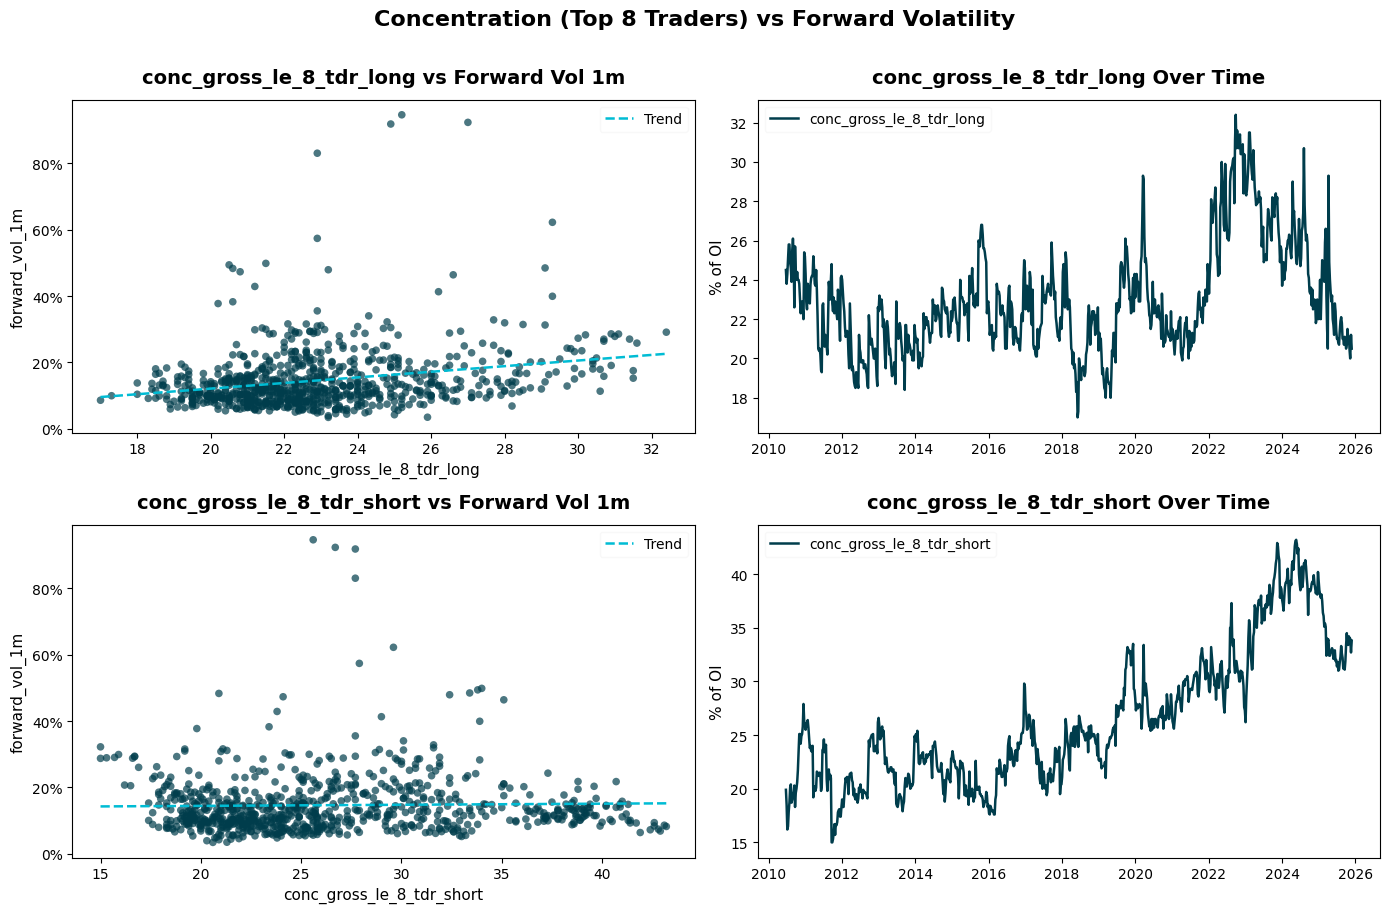

In [39]:
config_list_8 = []

for col in ['conc_gross_le_8_tdr_long', 'conc_gross_le_8_tdr_short']:
    config_list_8.append({
        'type': 'scatter',
        'data': conc_df,
        'x': col,
        'y': 'forward_vol_1m',
        'title': f"{col} vs Forward Vol 1m",
        'percent_y': True,
        'trend_line': True,
    })
    config_list_8.append({
        'type': 'line',
        'data': conc_df,
        'y': col,
        'title': f"{col} Over Time",
        'ylabel': '% of OI',
    })

plot_func.plot_subplots(plot_configs=config_list_8, ncols=2, suptitle='Concentration (Top 8 Traders) vs Forward Volatility')